# Setting

## Library

In [1]:
import os, sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Matplotlib global settings
mpl.rcParams["axes.titlesize"] = 14
mpl.rcParams["axes.labelsize"] = 20
plt.rcParams['savefig.dpi'] = 500
plt.rc('font', family='serif')

In [3]:
# ML libraries
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder

In [4]:
# Helper functions & model import
sys.path.append(os.path.join('..', 'src'))
from helper import makeSpecColors
from paths import *
from var import *
from sdtpy import *
from model import *

## Function

In [5]:
def select_uids_by_class(df, sample_number, class_col='Class', uid_col='uid', random_state=42):
    np.random.seed(random_state)
    uids_by_class = {}
    for c in df[class_col].unique():
        uids = df[df[class_col]==c][uid_col].unique()
        n_select = min(sample_number, len(uids))
        selected_uids = np.random.choice(uids, n_select, replace=False)
        uids_by_class[c] = set(selected_uids)
    return uids_by_class

In [6]:
def filter_by_selected_uids(df, uids_by_class, class_col='Class', uid_col='uid'):
    mask = np.zeros(len(df), dtype=bool)
    for c, uids in uids_by_class.items():
        mask |= ((df[class_col]==c) & (df[uid_col].isin(uids)))
    return df[mask]

In [7]:
from sklearn.model_selection import GroupShuffleSplit

def train_test_split_by_uid(df, test_size=0.2, class_col='Class', uid_col='uid', random_state=42):
    groups = df[uid_col]
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_idx, test_idx = next(gss.split(df, df[class_col], groups))
    return df.iloc[train_idx], df.iloc[test_idx]

## Initial Setup

In [8]:
logtxt = ""

In [9]:
# Set experiment configs
test_name = "LightGBM_feature_selection"
random_state = 42
test_size = 0.2
device_type = "cpu" # or gpu
n_jobs = -1
path_save = os.path.join(MODEL, test_name)
os.makedirs(path_save, exist_ok=True)

logtxt += "\nSet experiment configs\n"
logtxt += f"test_name: {test_name}\n"
logtxt += f"random_state: {random_state}\n"
logtxt += f"test_size: {test_size}\n"
logtxt += f"device_type: {device_type}\n"
logtxt += f"n_jobs: {n_jobs}\n"
logtxt += f"path_save: {path_save}\n"
logtxt += "\n"


In [10]:
path_data = os.path.join(FEATURE_BALANCED_DATA, 'features_40.csv')

logtxt += f"\nBalanced Data Set\n"

# Data

In [11]:
columns_to_use = list(data_dtype_dict.keys())

- Source to Consider

In [12]:
sources_to_consider = [
	"AGN", 
	"Ia", 
	"II", 
	"Ibc", 
	"LBV", 
	"TDE", 
	"Nova", 
	"M dwarf", 
	"CV",
	"SLSN",
]
logtxt += f"\nSources to consider: {sources_to_consider}\n"

In [13]:

data = pd.read_csv(
    path_data,
    engine='c', 
    # usecols=columns_to_use,
    # dtype=data_dtype_dict,
)

data['uid'] = data['uid'].astype(str)
data['Class'] = data['Class'].astype(str)

uids = data['uid'].values
classes = data['Class'].values

print(f"Balanced Data: {len(data)}")

logtxt += f"Balanced Data: {len(data)}\n"

indx_type_to_consider = np.where(
	np.array([(data['Class'] == source) for source in sources_to_consider]).any(axis=0)
)

print(f"{len(sources_to_consider)} sources to consider: {len(indx_type_to_consider[0])}")
data = data.iloc[indx_type_to_consider[0]]

logtxt += f"Balanced: {len(sources_to_consider)} sources to consider: {len(indx_type_to_consider[0])}\n"
logtxt += "\n"


Balanced Data: 282753
10 sources to consider: 282753


- Define GV, 1/4 random sampling, but wihtin the same uid

In [14]:
# Step 0: Define GV group and label
gv_classes = ["Nova", "M dwarf", "CV", "LBV"]
unified_label = "GV"

# Step 1: Initialize list to collect subsampled data
gv_subsample_list = []

# Step 2: For each GV class, sample a subset of rows per uid
for cls in gv_classes:
    cls_data = data[data['Class'] == cls]
    # Group by uid and sample {frac}% of each uid's samples (at least 1)
    sampled_data = cls_data.groupby('uid').apply(
        lambda df: df.sample(frac=0.25, random_state=42) if len(df) > 1 else df
    ).reset_index(drop=True)

    # Replace label to unified GV label
    sampled_data = sampled_data.copy()
    sampled_data['Class'] = unified_label
    gv_subsample_list.append(sampled_data)

# Step 3: Concatenate subsampled GV data
gv_data = pd.concat(gv_subsample_list, ignore_index=True)

# Step 4: Keep other classes unchanged
non_gv_data = data[~data['Class'].isin(gv_classes)]

# Step 5: Merge into final data
data = pd.concat([non_gv_data, gv_data], ignore_index=True)

# Step 6: Redefine sources_to_consider
sources_to_consider = [
    "AGN", 
    "Ia", 
    "II", 
    "Ibc", 
    "TDE", 
    "SLSN", 
    unified_label,
]
logtxt += f"\nSources to consider (with GV sampled): {sources_to_consider}\n"

# Step 7: Filter data again
indx_type_to_consider = np.where(
    np.array([(data['Class'] == source) for source in sources_to_consider]).any(axis=0)
)
print(f"{len(sources_to_consider)} sources to consider: {len(indx_type_to_consider[0])}")
data = data.iloc[indx_type_to_consider[0]]
logtxt += f"Balanced: {len(sources_to_consider)} sources to consider: {len(indx_type_to_consider[0])}\n\n"

# Step 8: Train/test split & encoding
X = data.drop(columns=['Sample_ID', 'Class', 'uid'])
y = data['Class']
X.fillna(-99, inplace=True)

gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
train_idx, test_idx = next(gss.split(X, y, groups=data['uid']))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

class_names = np.array([str(c) for c in label_encoder.inverse_transform(np.arange(len(label_encoder.classes_)))])
print("Balanced: Class mapping:", class_names)

7 sources to consider: 201000
Balanced: Class mapping: ['AGN' 'GV' 'II' 'Ia' 'Ibc' 'SLSN' 'TDE']


In [15]:
def plot_confusion_matrix():
    import seaborn as sns
    cm = confusion_matrix(y_test, y_pred)
    labels = label_encoder.classes_
    cm_percent = (cm / cm.sum(axis=1, keepdims=True)) * 100
    n_rows, n_cols = cm.shape
    combined_matrix = np.empty_like(cm, dtype=object)
    for i in range(n_rows):
        for j in range(n_cols):
            n = cm[i, j]
            p = cm_percent[i, j]
            combined_matrix[i, j] = f"{n:,}\n({p:.1f}%)"
    plt.figure(figsize=(12, 9))
    ax = sns.heatmap(cm_percent, annot=False, fmt="", cmap="Blues",
                        xticklabels=labels, yticklabels=labels,
                        cbar_kws={'label': '[%]'}, vmin=0, vmax=100)
    plt.xlabel("Predicted Label", fontsize=16)
    plt.ylabel("True Label", fontsize=16)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    # plt.title(__class__.__name__.replace("Experiment", ""))
    plt.tight_layout()
    thresh = 50
    for i in range(n_rows):
        for j in range(n_cols):
            value = cm_percent[i, j]
            text_color = "white" if value > thresh else "black"
            ax.text(j+0.5, i+0.5, combined_matrix[i, j], ha='center', va='center', color=text_color, fontsize=14)

In [16]:
params = {
    'boosting_type': 'gbdt',
    # 'objective': 'binary',               # 'multiclass' if multiclass
    'learning_rate': 0.1,
    'n_estimators': 100,
    'max_depth': -1,                     # no limit
    'num_leaves': 31,
    'min_child_samples': 20,
    'min_child_weight': 0.001,
    'subsample': 1.0,
    'subsample_freq': 0,
    'colsample_bytree': 1.0,
    'reg_alpha': 0.0,
    'reg_lambda': 0.0,
    'random_state': None,
    'n_jobs': n_jobs,
    'importance_type': 'split',
    # 'metric': 'binary_logloss',          # only used in train(), not in fit()
    'verbosity': -1,
    'device': 'cpu',                     # GPU 사용 시: 'gpu'
}

# Feature Selection and Train

In [17]:
import yaml

with open(f"{CONFIG}/feature.yaml", "r") as f:
    feature_dict = yaml.safe_load(f)

# print(type(data))
# print(data)
print(feature_dict['7DT_40'].keys())

colors = list(feature_dict['7DT_40']['color'])
residuals = list(feature_dict['7DT_40']['res1'])
gcolors = list(feature_dict['7DT_40']['semi_global_color'])

summary_dict = {
    'color-only': {'feature':colors, 'result':None},
    'residual-only': {'feature':residuals, 'result':None},
    'global_color-only': {'feature':gcolors, 'result':None},
    'color+residual': {'feature':colors+residuals, 'result':None},
    'color+global_color': {'feature':colors+gcolors, 'result':None},
    'residual+global_color': {'feature':residuals+gcolors, 'result':None},
    'all': {'feature':colors+residuals+gcolors, 'result':None},
}

dict_keys(['color', 'res1', 'semi_global_color'])


In [19]:
sub_X_train

,m400-m412,m400-m425,m400-m437,m400-m450,m400-m462,m400-m475,m400-m487,m400-m500,m400-m512,m400-m525,...,m837-m850,m837-m862,m837-m875,m837-m887,m850-m862,m850-m875,m850-m887,m862-m875,m862-m887,m875-m887
0,0.275862,0.275176,0.042380,0.054960,0.277564,0.295081,0.128994,-0.032542,0.046699,0.271643,...,-0.037682,0.146119,0.304476,0.326372,0.183801,0.342158,0.364055,0.158358,0.180254,0.021896
1,0.271619,0.256130,0.078812,0.078545,0.290370,0.307407,0.134478,-0.018277,0.058750,0.264723,...,-0.001278,0.244958,0.478401,0.320380,0.246236,0.479679,0.321658,0.233443,0.075422,-0.158021
2,0.284338,0.253445,0.027194,0.048467,0.275886,0.285545,0.112974,-0.038010,0.048735,0.272832,...,-0.071183,0.135506,0.288367,0.339879,0.206689,0.359550,0.411063,0.152861,0.204373,0.051512
3,0.285509,0.269352,0.044194,0.057014,0.274016,0.299376,0.127070,-0.038119,0.053407,0.262821,...,-0.055775,0.233408,0.339944,0.388831,0.289183,0.395719,0.444606,0.106535,0.155423,0.048888
4,0.367164,0.337500,0.085929,0.157977,0.386908,0.369541,0.258863,-0.020968,0.138924,0.384168,...,-0.664008,0.210785,0.155154,0.282102,0.874793,0.819162,0.946110,-0.055631,0.071317,0.126948
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200995,0.167139,0.354821,0.626157,0.651722,0.650706,0.904294,0.841892,0.906358,0.931643,0.966215,...,0.239493,-0.342875,1.365734,0.396482,-0.582367,1.126242,0.156989,1.708609,0.739357,-0.969253
200996,0.237641,0.277976,0.442586,0.575226,0.679203,0.747379,0.798516,0.858070,0.851272,0.876370,...,0.092387,0.160024,0.150192,0.104142,0.067637,0.057805,0.011755,-0.009832,-0.055882,-0.046050
200997,0.173231,0.261933,0.418844,0.528421,0.703902,0.693135,0.796117,0.852452,0.855259,0.847594,...,0.263034,0.064192,-0.183195,-0.168660,-0.198842,-0.446230,-0.431694,-0.247387,-0.232852,0.014536
200998,0.010242,-0.023959,0.191654,0.384974,0.598974,0.658118,0.599601,0.682402,0.654495,0.814506,...,-0.523758,-0.578940,-0.747090,-1.461830,-0.055182,-0.223332,-0.938072,-0.168150,-0.882890,-0.714740


In [21]:
import joblib
from lightgbm import LGBMClassifier


for key, values in summary_dict.items():
    features = values['feature']
    print(f"Test Name: {key}")

    # Feature Selection
    print("Feature Selection")
    sub_X_train = X_train[features]
    sub_X_test = X_test[features]
    
    # Model Train
    modelname = f"{path_save}/model_{key}.pkl"
    print(f"Train model")
    model = LGBMClassifier(**params)
    model.fit(
        sub_X_train, y_train,
        )
    y_pred = model.predict(sub_X_test)
    #
    print(f"Saving...")
    joblib.dump(model, modelname)
    print(f"Complete! ({modelname})")
    
    # Confusion Matrix
    print(f"Draw confusion matrix...")
    plot_confusion_matrix()
    plt.savefig(f"{path_save}/confusion_matrix_{key}.png")
    plt.close()
    print(f"Complete!")
    #
    print(f"Summrize the performance...")
    report_dict = classification_report(y_test, y_pred, target_names=class_names, output_dict=True)
    acc_value = report_dict.pop("accuracy")
    report_df = pd.DataFrame(report_dict).T
    tablename = f"{path_save}/report_{key}.csv"
    report_df.to_csv(tablename)
    summary_dict[key]['result'] = report_df
    print(f"Complete! {tablename}")

Test Name: color-only
Feature Selection
Train model
Saving...
Complete! (/home/gpaek/SED-Classifier/notebook/../model/LightGBM_feature_selection/model_color-only.pkl)
Draw confusion matrix...
Complete!
Summrize the performance...
Complete! /home/gpaek/SED-Classifier/notebook/../model/LightGBM_feature_selection/report_color-only.csv
Test Name: residual-only
Feature Selection
Train model
Saving...
Complete! (/home/gpaek/SED-Classifier/notebook/../model/LightGBM_feature_selection/model_residual-only.pkl)
Draw confusion matrix...
Complete!
Summrize the performance...
Complete! /home/gpaek/SED-Classifier/notebook/../model/LightGBM_feature_selection/report_residual-only.csv
Test Name: global_color-only
Feature Selection
Train model
Saving...
Complete! (/home/gpaek/SED-Classifier/notebook/../model/LightGBM_feature_selection/model_global_color-only.pkl)
Draw confusion matrix...
Complete!
Summrize the performance...
Complete! /home/gpaek/SED-Classifier/notebook/../model/LightGBM_feature_selecti

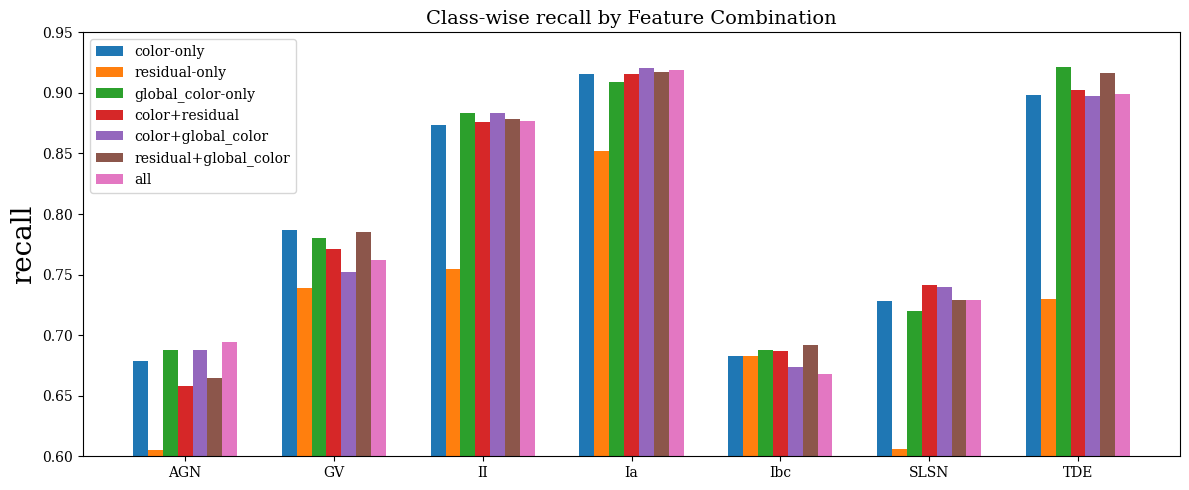

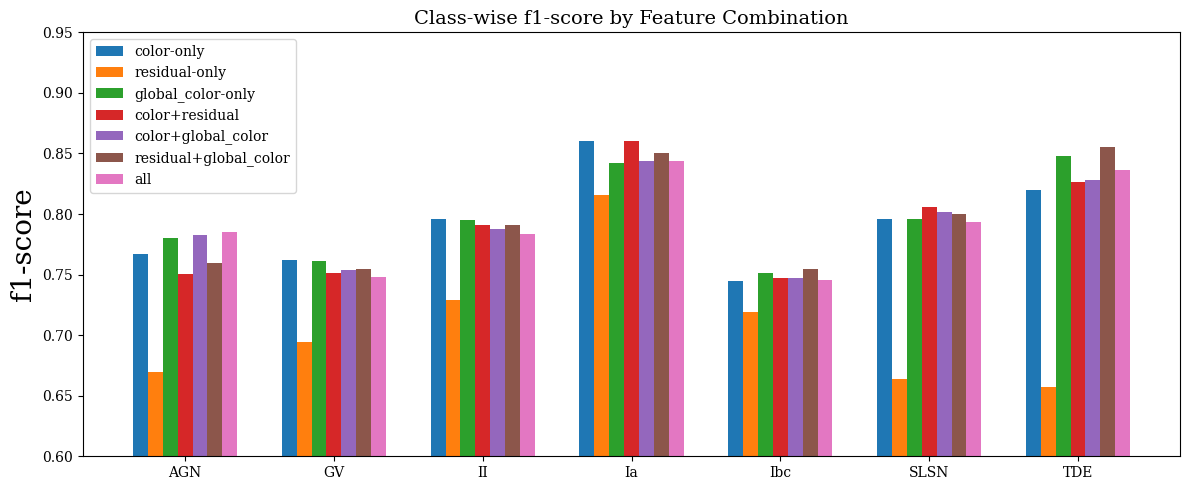

In [43]:
# 클래스명 리스트 (예: ['SNIa', 'SNII', 'Kilonova'])
class_names = summary_dict['color-only']['result'].index.tolist()
# 일반적으로 마지막 두 행은 'macro avg', 'weighted avg'임. 실제 클래스명만 추출
class_names = [name for name in class_names if 'avg' not in name and name != 'accuracy']

# 각 조합별 f1, precision, recall을 저장할 테이블 생성
comb_names = list(summary_dict.keys())
metrics = ['recall', 'f1-score']

# 각 metric별 클래스별 plot
for metric in metrics:
    plt.figure(figsize=(12,5))
    width = 0.1  # bar width
    x = np.arange(len(class_names))
    
    for i, comb in enumerate(comb_names):
        scores = summary_dict[comb]['result'].loc[class_names, metric]
        plt.bar(x + i*width, scores, width=width, label=comb)

    plt.xticks(x + width*(len(comb_names)-1)/2, class_names)
    plt.ylim(0.6, 0.95)
    plt.ylabel(metric)
    plt.title(f'Class-wise {metric} by Feature Combination')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{path_save}/classwise_{metric}_by_feature_comb.png")
    # plt.close()

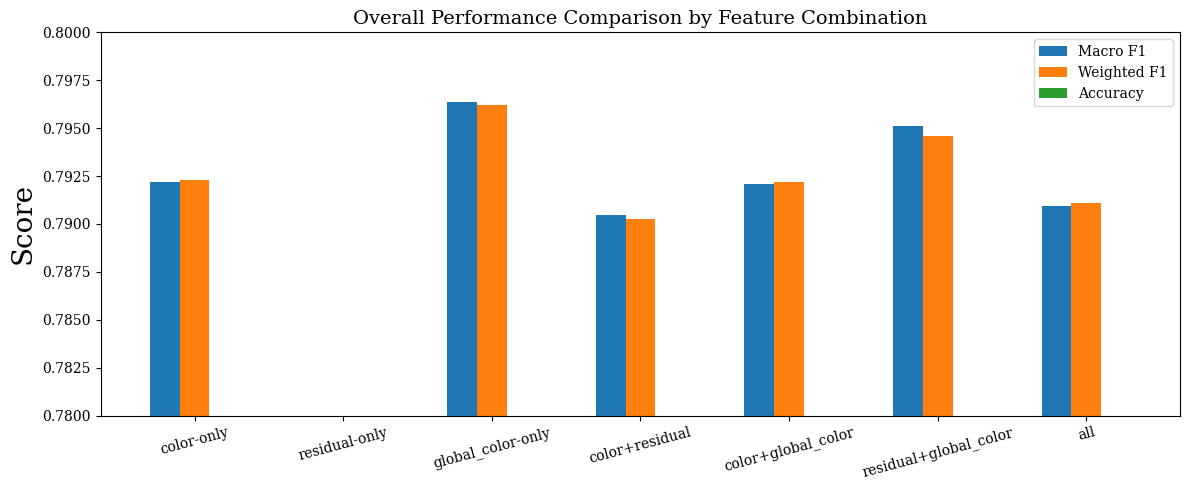

In [44]:
macro_f1 = []
weighted_f1 = []
accuracy = []
for comb in comb_names:
    report_df = summary_dict[comb]['result']
    # 원본 report_dict에서 accuracy값을 뽑아 summary_dict에 따로 저장해도 됩니다.
    # 여기서는 DataFrame에서 추출하는 로직
    macro_f1.append(report_df.loc['macro avg', 'f1-score'])
    weighted_f1.append(report_df.loc['weighted avg', 'f1-score'])
    # accuracy 값 가져오기 (DataFrame에 없다면 0 또는 np.nan으로 처리)
    if 'accuracy' in report_df.index:
        acc = report_df.loc['accuracy', 'f1-score'] if 'f1-score' in report_df.columns else report_df.loc['accuracy'][0]
    elif hasattr(summary_dict[comb], "acc_value"):
        acc = summary_dict[comb]['acc_value']
    else:
        acc = np.nan
    accuracy.append(acc)

# None 또는 np.nan을 0으로 변환 (plot이 에러나지 않게)
accuracy = [0 if (a is None or (isinstance(a, float) and np.isnan(a))) else a for a in accuracy]

x = np.arange(len(comb_names))

plt.figure(figsize=(12,5))
plt.bar(x-0.2, macro_f1, width=0.2, label='Macro F1')
plt.bar(x, weighted_f1, width=0.2, label='Weighted F1')
plt.bar(x+0.2, accuracy, width=0.2, label='Accuracy')
plt.xticks(x, comb_names, rotation=15)
plt.ylim(0.78, 0.8)
plt.ylabel('Score')
plt.title('Overall Performance Comparison by Feature Combination')
plt.legend()
plt.tight_layout()
plt.savefig(f"{path_save}/overall_performance_by_feature_comb.png")